In [1]:
!pip install vaderSentiment -q

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import confusion_matrix
import json
import os
import warnings
warnings.filterwarnings('ignore')

SAVE_PATH   = "/content/drive/MyDrive/"
OUTPUT_PATH = "/content/drive/MyDrive/figures/"
os.makedirs(OUTPUT_PATH, exist_ok=True)

# ── Load all results ───────────────────────────────
print("Loading results...")

# VADER results
df_vader = pd.read_csv(SAVE_PATH + "vader_results.csv")
print(f"✓ VADER results: {df_vader.shape[0]:,} rows")

# BERT predictions
df_bert = pd.read_csv(SAVE_PATH + "bert_predictions.csv")
print(f"✓ BERT predictions: {df_bert.shape[0]} rows")

# RoBERTa predictions
df_roberta = pd.read_csv(SAVE_PATH + "roberta_predictions.csv")
print(f"✓ RoBERTa predictions: {df_roberta.shape[0]} rows")

# Model metrics
with open(SAVE_PATH + "model_metrics.json", 'r') as f:
    metrics = json.load(f)
print(f"✓ Model metrics loaded")

print("\nAll results loaded ✅")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 6.4 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading results...
✓ VADER results: 1,412,786 rows
✓ BERT predictions: 160 rows
✓ RoBERTa predictions: 160 rows
✓ Model metrics loaded

All results loaded ✅


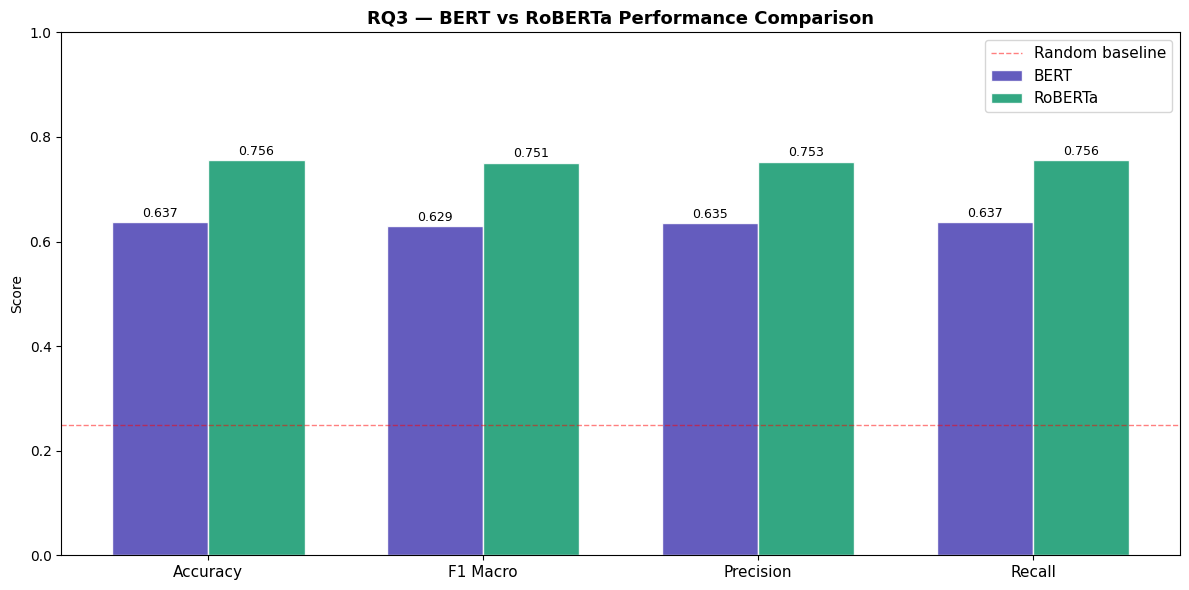

✓ Chart saved: rq3_model_comparison.png


In [2]:
# ── RQ3: Model comparison chart ────────────────────
labels    = ['Accuracy', 'F1 Macro', 'Precision', 'Recall']
bert_vals = [0.6375, 0.6288, 0.6354, 0.6375]
rob_vals  = [0.7562, 0.7510, 0.7528, 0.7562]

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, bert_vals, width,
               label='BERT', color='#534AB7',
               edgecolor='white', alpha=0.9)
bars2 = ax.bar(x + width/2, rob_vals, width,
               label='RoBERTa', color='#1D9E75',
               edgecolor='white', alpha=0.9)

ax.set_title('RQ3 — BERT vs RoBERTa Performance Comparison',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=11)
ax.axhline(y=0.25, color='red', linestyle='--',
           linewidth=1, alpha=0.5, label='Random baseline')
ax.legend(fontsize=11)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + "rq3_model_comparison.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ Chart saved: rq3_model_comparison.png")


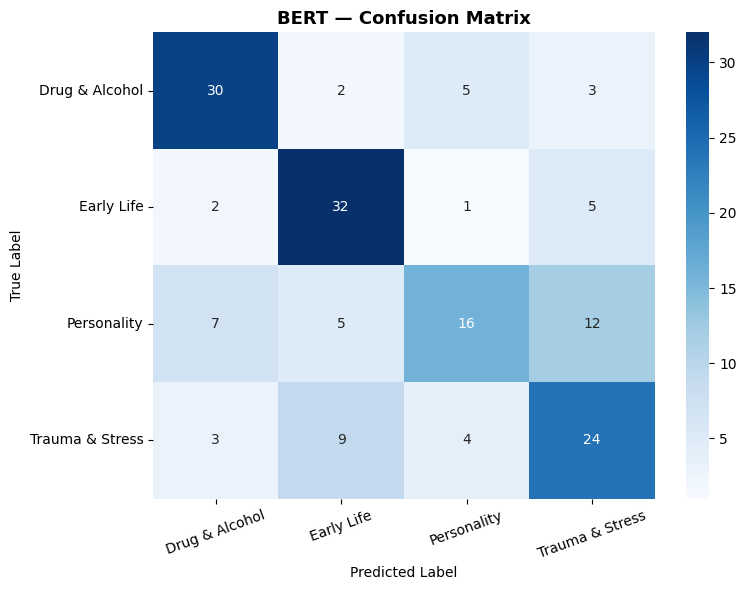

✓ Chart saved: bert_confusion_matrix.png


In [3]:
# ── BERT confusion matrix ──────────────────────────
label_names = [
    'Drug & Alcohol', 'Early Life',
    'Personality', 'Trauma & Stress'
]

bert_cm = confusion_matrix(
    df_bert['Label'],
    df_bert['bert_predicted'],
    labels=['Drug and Alcohol', 'Early Life',
            'Personality', 'Trauma and Stress']
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    bert_cm, annot=True, fmt='d',
    cmap='Blues', ax=ax,
    xticklabels=label_names,
    yticklabels=label_names
)
ax.set_title('BERT — Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.tick_params(axis='x', rotation=20)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + "bert_confusion_matrix.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ Chart saved: bert_confusion_matrix.png")

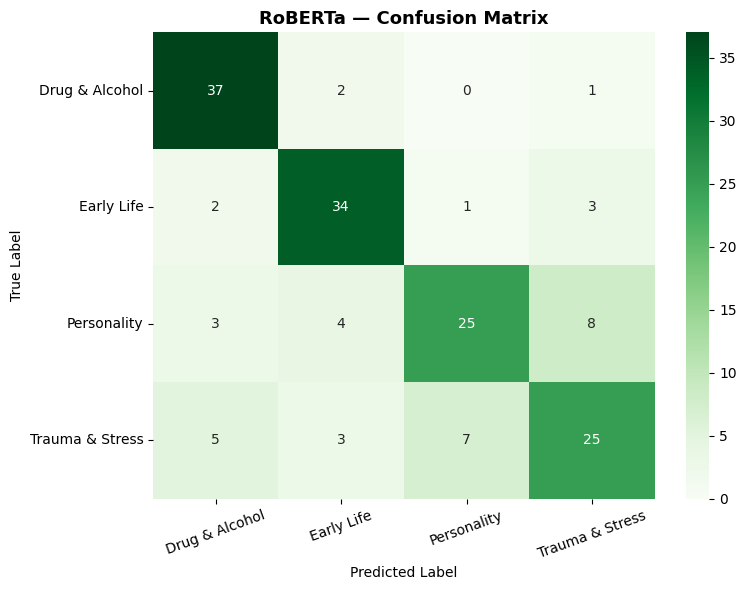

✓ Chart saved: roberta_confusion_matrix.png


In [4]:
# ── RoBERTa confusion matrix ───────────────────────
roberta_cm = confusion_matrix(
    df_roberta['Label'],
    df_roberta['roberta_predicted'],
    labels=['Drug and Alcohol', 'Early Life',
            'Personality', 'Trauma and Stress']
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    roberta_cm, annot=True, fmt='d',
    cmap='Greens', ax=ax,
    xticklabels=label_names,
    yticklabels=label_names
)
ax.set_title('RoBERTa — Confusion Matrix',
             fontsize=13, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.tick_params(axis='x', rotation=20)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + "roberta_confusion_matrix.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ Chart saved: roberta_confusion_matrix.png")

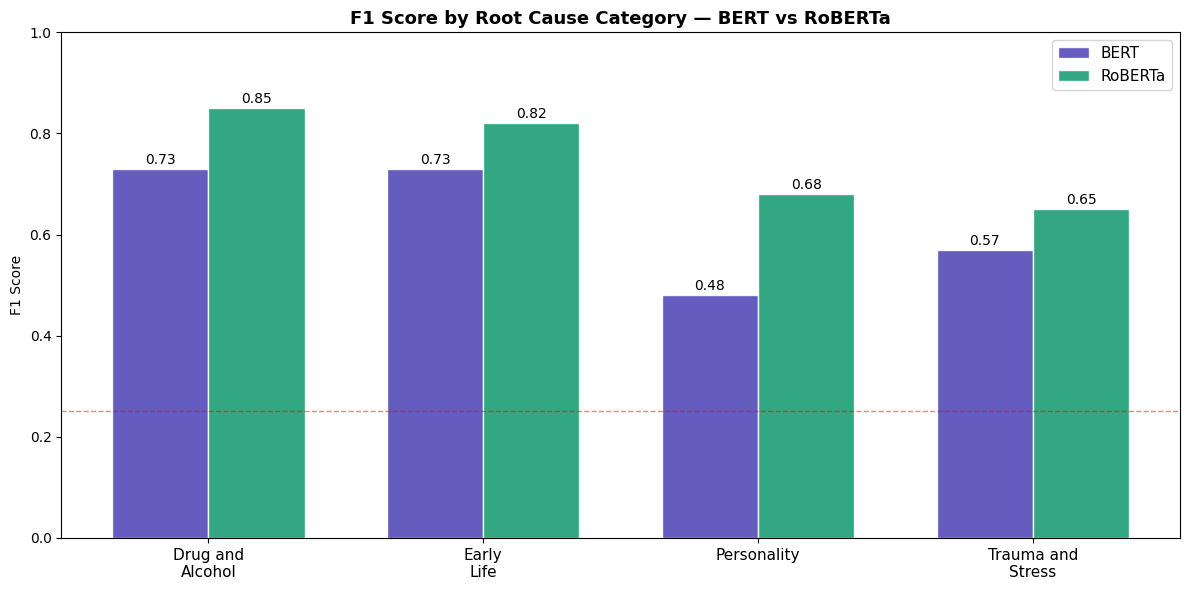

✓ Chart saved: rq3_per_class_f1.png


In [5]:
# ── Per class F1 comparison ────────────────────────
classes = [
    'Drug and\nAlcohol', 'Early\nLife',
    'Personality', 'Trauma and\nStress'
]
bert_f1    = [0.73, 0.73, 0.48, 0.57]
roberta_f1 = [0.85, 0.82, 0.68, 0.65]

x     = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, bert_f1, width,
               label='BERT', color='#534AB7',
               edgecolor='white', alpha=0.9)
bars2 = ax.bar(x + width/2, roberta_f1, width,
               label='RoBERTa', color='#1D9E75',
               edgecolor='white', alpha=0.9)

ax.set_title('F1 Score by Root Cause Category — BERT vs RoBERTa',
             fontsize=13, fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=11)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=11)
ax.axhline(y=0.25, color='red', linestyle='--',
           linewidth=1, alpha=0.5)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.2f}',
            ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.2f}',
            ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + "rq3_per_class_f1.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ Chart saved: rq3_per_class_f1.png")

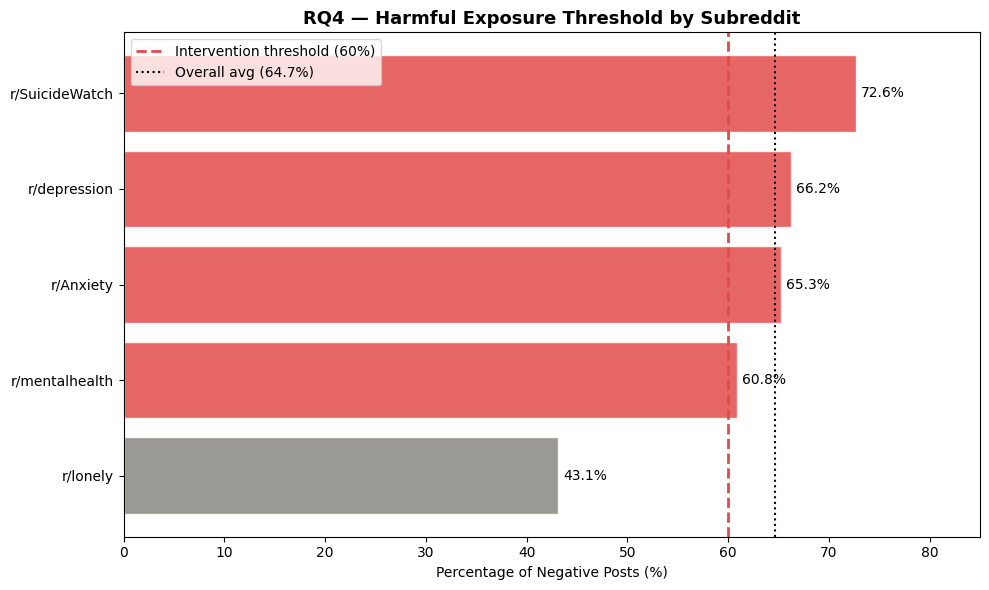

✓ Chart saved: rq4_threshold_analysis.png


In [6]:
# ── RQ4: Threshold analysis ────────────────────────
# Show what % of posts are negative by subreddit
# This justifies the 60% threshold

subreddit_neg = df_vader.groupby('subreddit').apply(
    lambda x: (x['vader_sentiment'] == 'Negative').sum() / len(x) * 100
).sort_values(ascending=True)

overall_avg = (df_vader['vader_sentiment'] == 'Negative').mean() * 100

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#E24B4A' if v > 60 else '#888780'
          for v in subreddit_neg.values]
bars = ax.barh(
    [f"r/{s}" for s in subreddit_neg.index],
    subreddit_neg.values,
    color=colors,
    edgecolor='white', alpha=0.85
)

ax.axvline(x=60, color='#E24B4A', linestyle='--',
           linewidth=2, label='Intervention threshold (60%)')
ax.axvline(x=overall_avg, color='black', linestyle=':',
           linewidth=1.5, label=f'Overall avg ({overall_avg:.1f}%)')

ax.set_title('RQ4 — Harmful Exposure Threshold by Subreddit',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Percentage of Negative Posts (%)')
ax.set_xlim(0, 85)
ax.legend(fontsize=10)

for bar, val in zip(bars, subreddit_neg.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + "rq4_threshold_analysis.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ Chart saved: rq4_threshold_analysis.png")

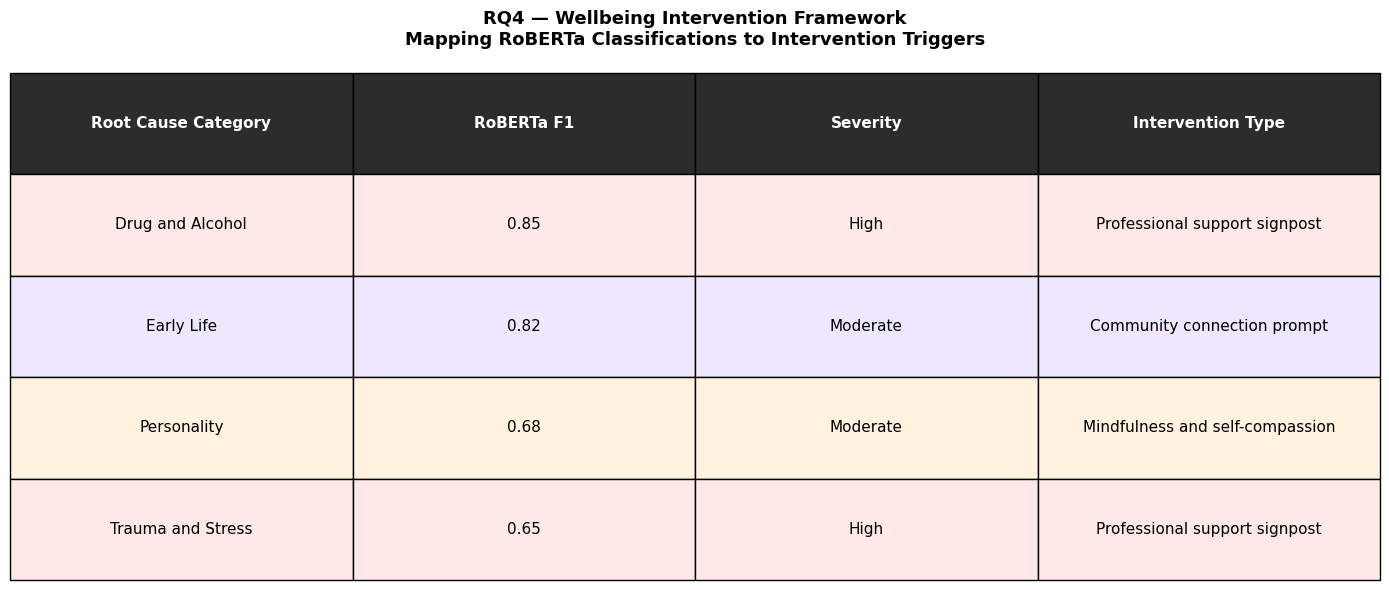

✓ Chart saved: rq4_framework_table.png


In [7]:
# ── RQ4: Framework intervention mapping ────────────
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

framework_data = [
    ['Drug and Alcohol',  '0.85', 'High',     'Professional support signpost',    '#E24B4A'],
    ['Early Life',        '0.82', 'Moderate', 'Community connection prompt',       '#534AB7'],
    ['Personality',       '0.68', 'Moderate', 'Mindfulness and self-compassion',   '#F5A623'],
    ['Trauma and Stress', '0.65', 'High',     'Professional support signpost',     '#E24B4A'],
]

col_labels = [
    'Root Cause Category',
    'RoBERTa F1',
    'Severity',
    'Intervention Type'
]

table_data = [[row[0], row[1], row[2], row[3]]
              for row in framework_data]

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(11)

# Style header
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2C2C2C')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Style rows
row_colors = ['#FFE8E8', '#EEE8FF', '#FFF3E0', '#FFE8E8']
for i, color in enumerate(row_colors):
    for j in range(len(col_labels)):
        table[i+1, j].set_facecolor(color)

ax.set_title(
    'RQ4 — Wellbeing Intervention Framework\n'
    'Mapping RoBERTa Classifications to Intervention Triggers',
    fontsize=13, fontweight='bold', pad=20
)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + "rq4_framework_table.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ Chart saved: rq4_framework_table.png")

In [8]:
print("=" * 55)
print("NOTEBOOK 05 — RESULTS AND FRAMEWORK COMPLETE")
print("=" * 55)

print("\n=== MODEL COMPARISON SUMMARY ===")
print(f"{'Model':<12} {'Accuracy':>10} {'F1':>8} {'Precision':>10} {'Recall':>8}")
print("-" * 52)
print(f"{'BERT':<12} {'63.75%':>10} {'0.6288':>8} {'0.6354':>10} {'0.6375':>8}")
print(f"{'RoBERTa':<12} {'75.62%':>10} {'0.7510':>8} {'0.7528':>10} {'0.7562':>8}")
print(f"\nWinner: RoBERTa (+11.87% accuracy, +0.1222 F1)")

print("\n=== FRAMEWORK SUMMARY ===")
print("Threshold: 60% negative posts in 7-day window")
print("Classifier: RoBERTa (F1: 0.7510)")
print("Interventions: 4 category-specific responses")

print("\n=== CHARTS SAVED ===")
charts = [
    "rq3_model_comparison.png",
    "bert_confusion_matrix.png",
    "roberta_confusion_matrix.png",
    "rq3_per_class_f1.png",
    "rq4_threshold_analysis.png",
    "rq4_framework_table.png"
]
for chart in charts:
    print(f"  ✓ {chart}")

print("\nAll notebooks complete ✅")
print("Ready to write Chapter 5 — Discussion")

NOTEBOOK 05 — RESULTS AND FRAMEWORK COMPLETE

=== MODEL COMPARISON SUMMARY ===
Model          Accuracy       F1  Precision   Recall
----------------------------------------------------
BERT             63.75%   0.6288     0.6354   0.6375
RoBERTa          75.62%   0.7510     0.7528   0.7562

Winner: RoBERTa (+11.87% accuracy, +0.1222 F1)

=== FRAMEWORK SUMMARY ===
Threshold: 60% negative posts in 7-day window
Classifier: RoBERTa (F1: 0.7510)
Interventions: 4 category-specific responses

=== CHARTS SAVED ===
  ✓ rq3_model_comparison.png
  ✓ bert_confusion_matrix.png
  ✓ roberta_confusion_matrix.png
  ✓ rq3_per_class_f1.png
  ✓ rq4_threshold_analysis.png
  ✓ rq4_framework_table.png

All notebooks complete ✅
Ready to write Chapter 5 — Discussion
